In [0]:
retail_df = spark.read.format("delta") \
.load("dbfs:/FileStore/silver/retail")

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000.0,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000.0,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000.0,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000.0,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000.0,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000.0,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000.0,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000.0,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000.0,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000.0,2026-06,High Value


In [0]:
retail_df.createOrReplaceTempView("retail")

In [0]:
%sql
SELECT SUM(revenue) AS total_revenue
FROM retail;

total_revenue
336000.0


In [0]:
%sql
SELECT city,
SUM(revenue) revenue
FROM retail
GROUP BY city
ORDER BY revenue DESC;

city,revenue
Hyderabad,135000.0
Delhi,89000.0
Bangalore,50000.0
Mumbai,21000.0
Chennai,18000.0
Kochi,15000.0
Pune,8000.0


In [0]:
%sql
SELECT category,
SUM(revenue) revenue
FROM retail
GROUP BY category
ORDER BY revenue DESC;

category,revenue
Electronics,250000.0
Furniture,45000.0
Fashion,41000.0


In [0]:
%sql
SELECT customer_name,
SUM(revenue) revenue
FROM retail
GROUP BY customer_name
ORDER BY revenue DESC;

customer_name,revenue
Rahul Sharma,90000.0
Sneha Patel,89000.0
Priya Reddy,50000.0
Arjun Verma,45000.0
Amit Kumar,21000.0
Farhan Ali,18000.0
Meera Nair,15000.0
Neha Singh,8000.0


In [0]:
%sql
SELECT *
FROM retail
WHERE status='Completed';

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000.0,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000.0,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000.0,2026-06,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000.0,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000.0,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000.0,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000.0,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000.0,2026-06,High Value


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
product_rank = retail_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

window_spec = Window.orderBy(desc("revenue"))

product_rank = product_rank.withColumn(
    "rank",
    rank().over(window_spec)
)

display(product_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


product_name,revenue,rank
Laptop,130000.0,1
Mobile,75000.0,2
TV,45000.0,3
Table,24000.0,4
Chair,21000.0,5
Shoes,18000.0,6
Bag,15000.0,7
Watch,8000.0,8


In [0]:
customer_rank = retail_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("revenue")
)

customer_rank = customer_rank.withColumn(
    "rank",
    rank().over(window_spec)
)

display(customer_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_name,revenue,rank
Rahul Sharma,90000.0,1
Sneha Patel,89000.0,2
Priya Reddy,50000.0,3
Arjun Verma,45000.0,4
Amit Kumar,21000.0,5
Farhan Ali,18000.0,6
Meera Nair,15000.0,7
Neha Singh,8000.0,8


In [0]:
display(
    customer_rank.filter(col("rank") <= 3)
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_name,revenue,rank
Rahul Sharma,90000.0,1
Sneha Patel,89000.0,2
Priya Reddy,50000.0,3


In [0]:
category_product = retail_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

window_cat = Window.partitionBy(
    "category"
).orderBy(desc("revenue"))

top_product = category_product.withColumn(
    "rank",
    rank().over(window_cat)
).filter("rank=1")

display(top_product)

category,product_name,revenue,rank
Electronics,Laptop,130000.0,1
Fashion,Shoes,18000.0,1
Furniture,Table,24000.0,1


In [0]:
daily_revenue = retail_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("daily_revenue")
)

window_run = Window.orderBy("order_date")

running_revenue = daily_revenue.withColumn(
    "running_revenue",
    sum("daily_revenue").over(window_run)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


order_date,daily_revenue,running_revenue
2026-06-01,115000.0,115000.0
2026-06-02,45000.0,160000.0
2026-06-03,26000.0,186000.0
2026-06-04,60000.0,246000.0
2026-06-05,90000.0,336000.0


In [0]:
retail_df.write.format("delta") \
.mode("overwrite") \
.save("dbfs:/FileStore/gold/retail")

In [0]:
retail_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("gold_retail")

In [0]:
%sql
CREATE OR REPLACE TABLE retail_sql
USING DELTA
AS
SELECT * FROM retail;

num_affected_rows,num_inserted_rows


In [0]:
%sql
DESCRIBE HISTORY gold_retail;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T15:04:59.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1082453304901866),bf7e6999-2547-4a06-b48a-17a372128922,0622-143213-yk6jrhu1-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5859)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
old_version = spark.read.format("delta") \
.option("versionAsOf",0) \
.table("gold_retail")

display(old_version)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000.0,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000.0,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000.0,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000.0,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000.0,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000.0,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000.0,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000.0,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000.0,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000.0,2026-06,High Value


In [0]:
updated_customer = spark.createDataFrame([
("C101","Rahul Sharma","Chennai","Tamil Nadu","Premium")
],
["customer_id","customer_name","city","state","customer_type"])

updated_customer.createOrReplaceTempView("updates")

In [0]:
%sql
MERGE INTO gold_retail t
USING updates s
ON t.customer_id=s.customer_id

WHEN MATCHED THEN
UPDATE SET
t.customer_name=s.customer_name,
t.city=s.city,
t.state=s.state,
t.customer_type=s.customer_type

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
2,2,0,0


In [0]:
%sql
DESCRIBE HISTORY gold_retail;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T15:05:58.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(1082453304901866),8e49d1df-7680-4682-ba08-be767a482075,0622-143213-yk6jrhu1-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 2, numRemovedBytes -> 10848, p25FileSize -> 5887, numDeletionVectorsRemoved -> 1, minFileSize -> 5887, numAddedFiles -> 1, maxFileSize -> 5887, p75FileSize -> 5887, p50FileSize -> 5887, numAddedBytes -> 5887)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T15:05:56.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(customer_id#17563 = customer_id#17511)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [])",null,List(1082453304901866),8e49d1df-7680-4682-ba08-be767a482075,0622-143213-yk6jrhu1-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 4989, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4459, materializeSourceTimeMs -> 342, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1930, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2080)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T15:04:59.000Z,142474429042272,azuser7224_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1082453304901866),bf7e6999-2547-4a06-b48a-17a372128922,0622-143213-yk6jrhu1-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5859)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
OPTIMIZE gold_retail;

path,metrics
abfss://unity-catalog-storage@dbstorage4dl7qidbvwokm.dfs.core.windows.net/7405612650996481/__unitystorage/catalogs/00aa3a5b-66d6-498b-b2b0-ec8d8be5f4b2/tables/c04d266c-cb1d-42ee-9817-523bef7e1e9d,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782140789967, 1782140790391, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE gold_retail
ZORDER BY(city);

path,metrics
abfss://unity-catalog-storage@dbstorage4dl7qidbvwokm.dfs.core.windows.net/7405612650996481/__unitystorage/catalogs/00aa3a5b-66d6-498b-b2b0-ec8d8be5f4b2/tables/c04d266c-cb1d-42ee-9817-523bef7e1e9d,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5887), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782140816257, 1782140816816, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
VACUUM gold_retail RETAIN 168 HOURS;

path
abfss://unity-catalog-storage@dbstorage4dl7qidbvwokm.dfs.core.windows.net/7405612650996481/__unitystorage/catalogs/00aa3a5b-66d6-498b-b2b0-ec8d8be5f4b2/tables/c04d266c-cb1d-42ee-9817-523bef7e1e9d


In [0]:
import matplotlib.pyplot as plt

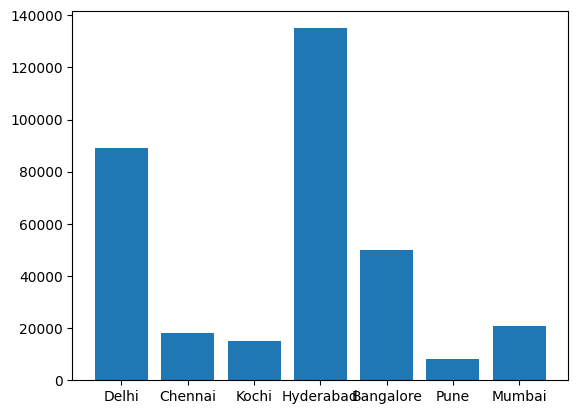

In [0]:
city_df = retail_df.groupBy("city").sum("revenue").toPandas()

plt.bar(city_df["city"], city_df["sum(revenue)"])
plt.show()

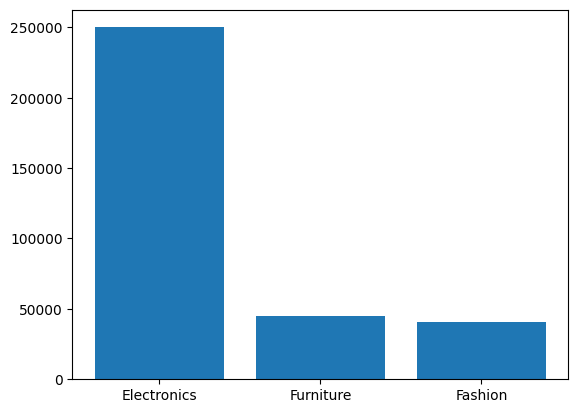

In [0]:
cat_df = retail_df.groupBy("category").sum("revenue").toPandas()

plt.bar(cat_df["category"], cat_df["sum(revenue)"])
plt.show()

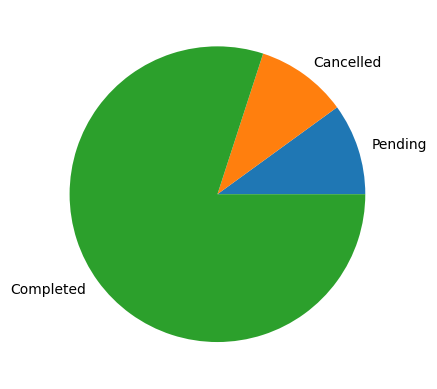

In [0]:
status_df = retail_df.groupBy("status").count().toPandas()

plt.pie(status_df["count"],labels=status_df["status"])
plt.show()

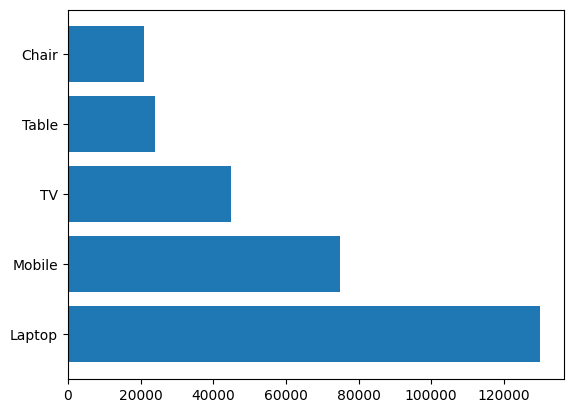

In [0]:
top_prod = retail_df.groupBy("product_name") \
.sum("revenue") \
.orderBy("sum(revenue)",ascending=False) \
.limit(5) \
.toPandas()

plt.barh(top_prod["product_name"],
         top_prod["sum(revenue)"])
plt.show()

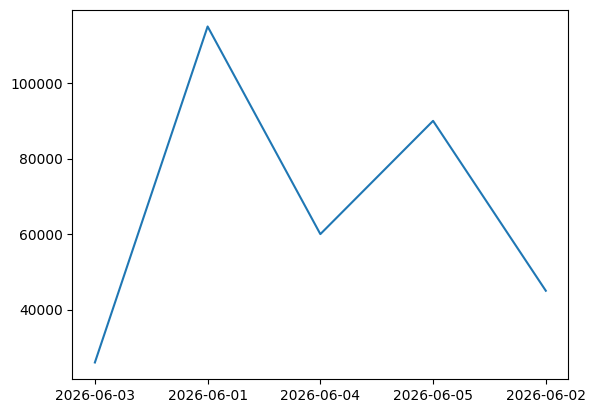

In [0]:
trend = retail_df.groupBy("order_date") \
.sum("revenue") \
.toPandas()

plt.plot(trend["order_date"],
         trend["sum(revenue)"])

plt.show()

In [0]:
%sql
CREATE TABLE managed_retail
USING DELTA
AS SELECT * FROM retail;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
default,gold_retail,false
default,managed_retail,false
default,retail_sql,false
,retail,true
,temp_retail,true
,updates,true


In [0]:
%sql
SELECT * FROM temp_retail;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000.0,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000.0,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000.0,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000.0,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000.0,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000.0,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000.0,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000.0,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000.0,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000.0,2026-06,High Value


In [0]:
%sql
CREATE OR REPLACE GLOBAL TEMP VIEW global_retail
AS
SELECT * FROM retail;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8535292110555598>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', 'CREATE OR REPLACE GLOBAL TEMP VIEW global_retail\nAS\nSELECT * FROM retail;\n')

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:213, in SqlMagic.sql(self, line, cell)
    206 except BaseException as e:
  